## Predictive Model Findings

- Built a Linear Regression model to predict Sales using product category features (Segment, Category, Sub-Category, Region).
- **R² = 0.32** — the model explains ~32% of the variance in Sales.
- **MAE = $65.89**, **RMSE = $93.47** — average prediction error.
- **Top drivers of higher sales:** Copiers, Machines, Tables.
- **Associated with lower sales:** Fasteners, Furnishings, Office Supplies.
- Note: numeric fields like Quantity, Discount, and Profit were not present in the cleaned dataset, so this model relies on categorical product/region information only.

In [15]:
# Encode categorical features to predict Sales
features = pd.get_dummies(df[['Segment', 'Category', 'Sub-Category', 'Region']], drop_first=True)
target = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("R²:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

importance = pd.Series(model.coef_, index=features.columns).sort_values(ascending=False)
print("\nTop 3 features (increase sales):\n", importance.head(3))
print("\nBottom 3 features (decrease sales):\n", importance.tail(3))

R²: 0.3227991313101578
MAE: 65.88591547980518
RMSE: 93.4672077335067

Top 3 features (increase sales):
 Sub-Category_Copiers     300.903425
Sub-Category_Machines    121.519831
Sub-Category_Tables       96.570714
dtype: float64

Bottom 3 features (decrease sales):
 Sub-Category_Fasteners     -57.246815
Sub-Category_Furnishings   -97.561517
Category_Office Supplies   -99.491572
dtype: float64


In [14]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

## Customer Segmentation Findings

- **Cluster 0 (VIP):** Highest total sales (~$2,122) and order frequency (9.1) — target with loyalty rewards and early access to promotions.
- **Cluster 1 (Regular High-Value):** Moderate-high spend (~$1,080), lower frequency (5.1) — encourage repeat purchases with personalized offers.
- **Cluster 2 (Frequent, Lower-Value):** Frequent orders (7.9) but lower spend per order (~$1,066) — good candidates for upsell/cross-sell campaigns.
- **Cluster 3 (Occasional):** Lowest spend (~$393) and frequency (3.5) — re-engagement campaigns or win-back offers.

In [12]:
cluster_profile = customer_data.groupby('Cluster')[['TotalSales', 'Frequency']].mean()
cluster_profile

,TotalSales,Frequency
Cluster,,
0,2121.600910,9.104839
1,1080.442036,5.119658
2,1066.233482,7.894444
3,392.608706,3.543651


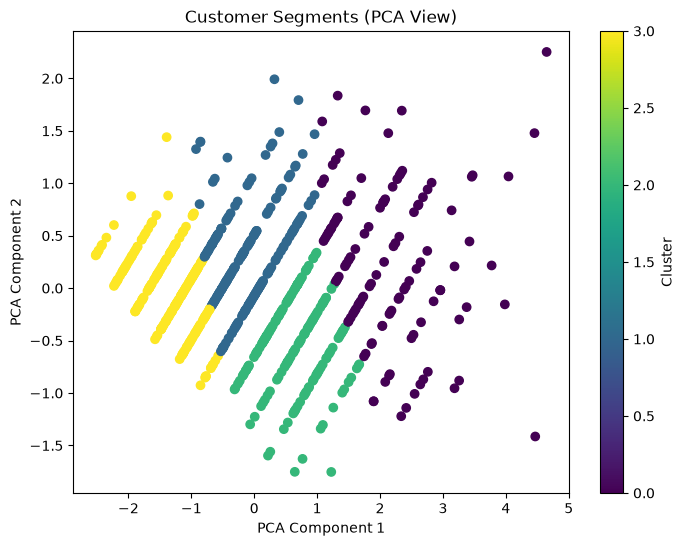

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(scaled)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1], c=customer_data['Cluster'], cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (PCA View)')
plt.colorbar(scatter, label='Cluster')
plt.show()

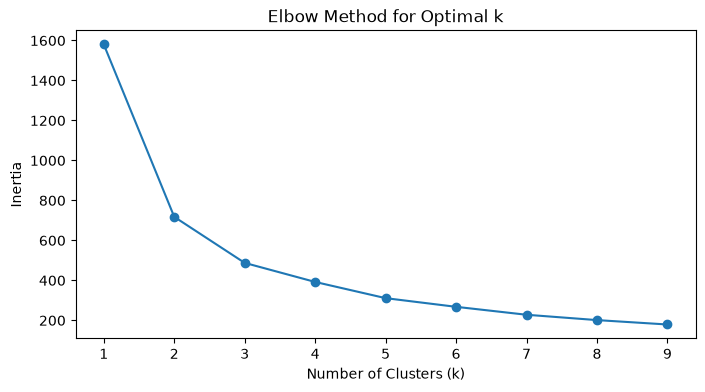

In [10]:
scaler = StandardScaler()
scaled = scaler.fit_transform(customer_data)

inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1,10), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [9]:
customer_data = df.groupby('Customer ID').agg({
    'Sales': 'sum',
    'Order ID': 'nunique'
}).rename(columns={'Order ID': 'Frequency', 'Sales': 'TotalSales'})

customer_data.head()

,TotalSales,Frequency
Customer ID,,
AA-10315,959.920,5
AA-10375,1056.390,9
AA-10480,1790.512,4
AA-10645,1088.700,6
AB-10015,886.156,3


## Time Series Analysis Findings

- Sales show a clear **upward trend** over the analyzed period.
- There is strong **yearly seasonality**, with sales spiking every November-December (holiday shopping season).
- Residuals are randomly scattered around zero, indicating the trend + seasonality model captures the pattern well.

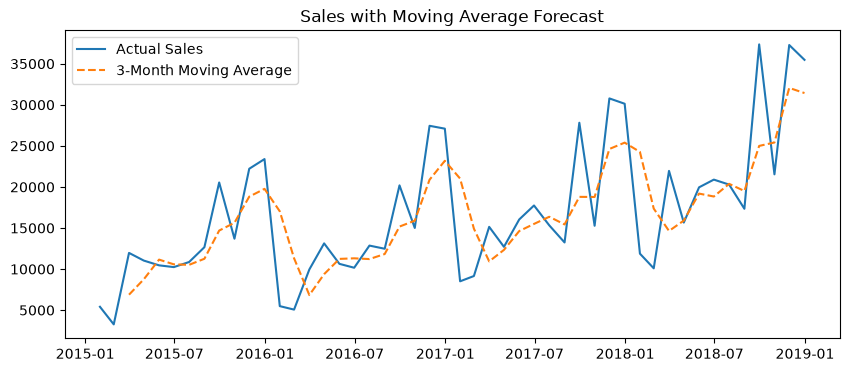

In [8]:
ts_ma = ts.rolling(window=3).mean()

plt.figure(figsize=(10,4))
plt.plot(ts, label='Actual Sales')
plt.plot(ts_ma, label='3-Month Moving Average', linestyle='--')
plt.title('Sales with Moving Average Forecast')
plt.legend()
plt.show()

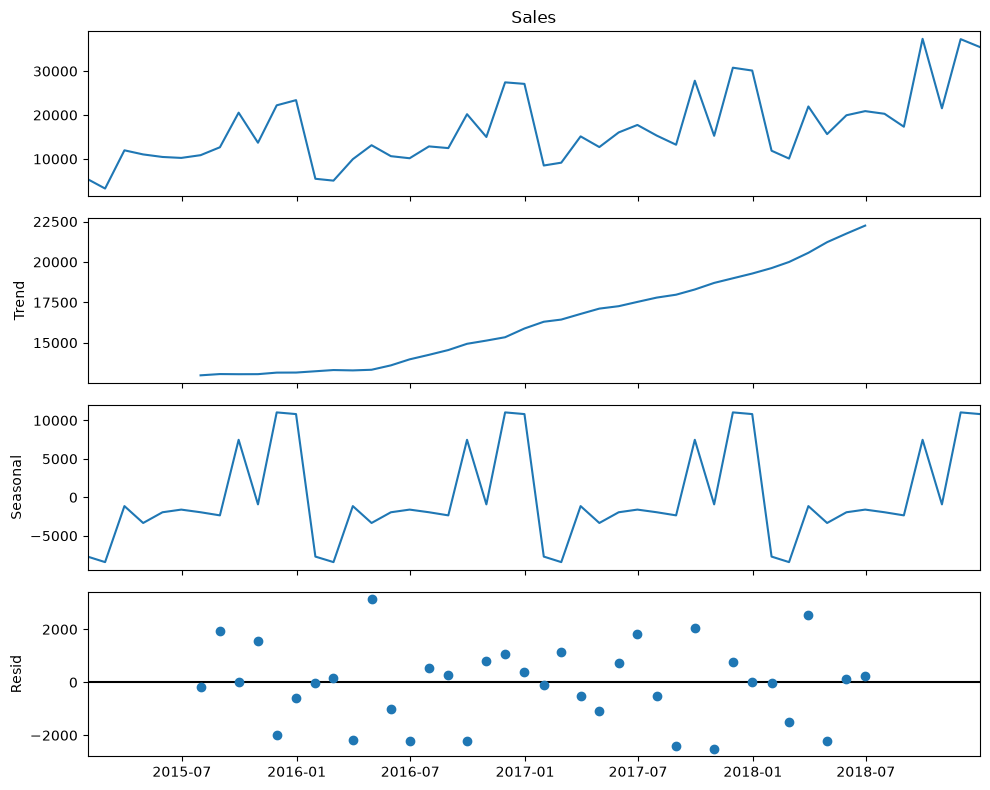

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

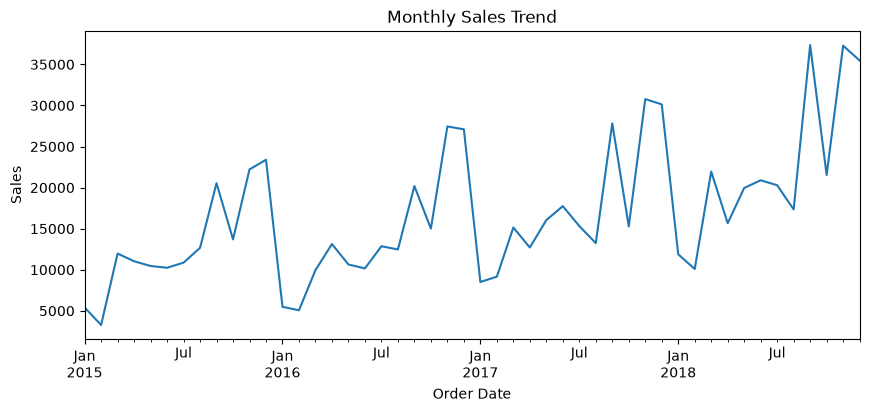

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
ts = df.set_index('Order Date')['Sales'].resample('ME').sum()
ts.plot(figsize=(10,4), title='Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

## Statistical Analysis Findings

- **t-test (South vs West Sales):** p = 0.0944 (not significant, p > 0.05) — no meaningful difference in average sales between these two regions.
- **Chi-square (Category vs Region):** p = 0.7451 (not significant) — product category distribution doesn't meaningfully depend on region.
- **95% Confidence Interval for mean Sales:** ($90.80, $95.63) — we're 95% confident the true average sale amount falls in this range.

In [5]:
# chi-square: relationship between Category and Region
contingency = pd.crosstab(df['Category'], df['Region'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"chi-square: chi2={chi2:.3f}, p={p:.4f}, dof={dof}")

# 95% confidence interval for mean Sales
mean_sales = df['Sales'].mean()
sem = stats.sem(df['Sales'])
ci = stats.t.interval(0.95, len(df)-1, loc=mean_sales, scale=sem)
print(f"\n95% CI for mean Sales: ({ci[0]:.2f}, {ci[1]:.2f})")

chi-square: chi2=3.492, p=0.7451, dof=6

95% CI for mean Sales: (90.80, 95.63)


In [4]:
# Descriptive statistics
print(df['Sales'].describe())
print("\nSkewness:", df['Sales'].skew())

# t-test: compare Sales between two regions
south = df[df['Region'] == 'South']['Sales']
west = df[df['Region'] == 'West']['Sales']
t_stat, p_val = stats.ttest_ind(south, west)
print(f"\nt-test (South vs West Sales): t={t_stat:.3f}, p={p_val:.4f}")

count    8655.000000
mean       93.213330
std       114.693292
min         0.444000
25%        15.014000
50%        40.880000
75%       124.382000
max       500.240000
Name: Sales, dtype: float64

Skewness: 1.6852666581225026

t-test (South vs West Sales): t=-1.673, p=0.0944


In [3]:
df = pd.read_csv('../data/cleaned_superstore.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960
1,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620
2,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368
3,6,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860
4,7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Matplotlib is building the font cache; this may take a moment.
